# Myelin 4-Class Diagnosis Classifier
**Classes:** `normal`, `preterm`, `HIE`, `hydrocephalus`

Mixed/comorbid cases (e.g. preterm & HIE, preterm & hydrocephalus) are folded into the **preterm** class, on the rationale that prematurity is the dominant structural confound (white-matter/ventricular changes) and these subjects should not be presented to the model as 'pure' HIE or hydrocephalus.

This notebook uses the same MRI preprocessing pipeline and the same training protocol (5-fold stratified CV, weighted sampler, focal loss, post-hoc threshold calibration) as the original 3-class `normal / HIE / hydrocephalus` classifier, extended to 4 classes. The backbone (3D ResNet-18, MONAI) is trained **from random initialization** — no pretrained age-regression checkpoint is used.

> ⚠️ **Runtime:** Set to `T4 GPU` via Runtime → Change runtime type → GPU

## 1. Install dependencies

In [ ]:
#pip install -q nibabel nilearn scikit-learn monai einops

## 2. Download the dataset from Zenodo

In [1]:
import os

DATA_DIR = "../myelin_dataset"
os.makedirs(DATA_DIR, exist_ok=True)

# Download from Zenodo record 8055666
#!zenodo_get 10.5281/zenodo.8055666 -o {DATA_DIR}

!ls {DATA_DIR} | head -20

atlas
meta.csv
s0001
s0002
s0003
s0004
s0005
s0006
s0007
s0008
s0009
s0010
s0011
s0012
s0013
s0014
s0015
s0016
s0017
s0018


## 3. Inspect and prepare metadata

In [2]:
import pandas as pd
import glob
import numpy as np
import os

meta_path = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)[0]
df = pd.read_csv(meta_path, sep=';')
df = df.dropna(subset=['age', 'age_corrected']).copy()
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\n=== diagnosis distribution ===")
print(df['diagnosis'].value_counts())
df.head()

Shape: (833, 7)
Columns: ['image_id', 'myelinisation', 'age', 'age_corrected', 'doctor_predicted_age', 'diagnosis', 'group']

=== diagnosis distribution ===
diagnosis
normal                             565
HIE                                 45
Hydrocephalus                       30
Infarct                             21
Meningitis                          17
                                  ... 
neuroectodermal tumor                1
cerebral atrophy, hydrocephalus      1
Normal                               1
Premature, PVL, Hydrocephalus        1
medulloblastoma                      1
Name: count, Length: 73, dtype: int64


,image_id,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group
0,s0001,normal,22,22,22,normal,train
1,s0002,normal,29,29,29,normal,train
2,s0003,normal,4,4,4,normal,train
3,s0004,normal,0,0,0,normal,train
4,s0005,normal,0,0,0,normal,train


## 4. Build file paths and filter subjects with both T1w + T2w

In [3]:
import os, glob

df = df.dropna(subset=['age', 'age_corrected']).copy()
print(f"Subjects with valid age/age_corrected: {len(df)}")

def find_nifti(subject_id, modality, data_dir):
    """Find an N4 bias-field-corrected NIfTI file for a given subject and modality (t1 or t2)."""
    path = os.path.join(data_dir, subject_id, f"{modality}_n4.nii.gz")
    if os.path.exists(path):
        return path
    return None

id_col = next(c for c in ['subject', 'subject_id', 'sub', 'id', 'SubjectID', 'image_id'] if c in df.columns)
print(f"Using ID column: {id_col}")

t1_paths, t2_paths, valid_idx = [], [], []
for i, row in df.iterrows():
    sid = str(row[id_col])
    t1 = find_nifti(sid, 't1', DATA_DIR)
    t2 = find_nifti(sid, 't2', DATA_DIR)
    if t1 and t2:
        t1_paths.append(t1)
        t2_paths.append(t2)
        valid_idx.append(i)

df_valid = df.loc[valid_idx].copy()
df_valid['t1_path'] = t1_paths
df_valid['t2_path'] = t2_paths
print(f"Subjects with both T1w + T2w found: {len(df_valid)}")

Subjects with valid age/age_corrected: 833
Using ID column: image_id
Subjects with both T1w + T2w found: 833


## 5. MONAI transforms — resize + normalise 3-D volumes

In [4]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Spacingd, Orientationd, ScaleIntensityRangePercentilesd,
    Resized, ConcatItemsd, ToTensord
)

TARGET_SHAPE = (64, 64, 64)   # Reduce if OOM; increase for better accuracy

mri_transforms = Compose([
    LoadImaged(keys=['t1', 't2']),
    EnsureChannelFirstd(keys=['t1', 't2']),
    Orientationd(keys=['t1', 't2'], axcodes='RAS'),
    Spacingd(keys=['t1', 't2'], pixdim=(2.0, 2.0, 2.0), mode='bilinear'),
    ScaleIntensityRangePercentilesd(keys=['t1', 't2'], lower=1, upper=99,
                                     b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=['t1', 't2'], spatial_size=TARGET_SHAPE),
    ConcatItemsd(keys=['t1', 't2'], name='image', dim=0),  # → (2, D, H, W)
    ToTensord(keys=['image'])
])

## 6. Device setup
No pretrained backbone is used — the classifier's ResNet-18 is trained from random initialization.

In [5]:
import torch
import torch.nn as nn
from monai.networks.nets import resnet18

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 7. BRAIN CLASSIFIER — normal / preterm / HIE / hydrocephalus
Same protocol as the original 3-class classifier:
- 5-fold stratified cross-validation
- ResNet-18 backbone trained from random initialization (no pretrained checkpoint)
- Class-balanced **weighted sampler** during training
- **Focal loss** (γ=1) with inverse-frequency class weights
- Checkpoint save/skip per fold, best fold (by macro F1) kept as the deployment model
- Post-hoc per-class threshold calibration on pooled CV predictions

**Label logic (4-class, mixed cases folded into preterm):**
```
normal           → diagnosis == 'normal'
preterm          → 'preterm'/'premature' in diagnosis
                    (this also captures preterm+HIE and preterm+hydrocephalus comorbidity —
                     these mixed cases are NOT given their own class and are NOT dropped)
HIE              → 'hie'/'hypoxic' in diagnosis AND not preterm
hydrocephalus    → 'hydrocephal' in diagnosis AND not preterm
(everything else, e.g. polymicrogyria, excluded — same as original)
```

=== Classifier dataset (4-class, mixed cases folded into preterm) ===
label_clf
normal           566
HIE               50
hydrocephalus     32
preterm           27
Name: count, dtype: int64
Total: 675

Preterm subjects with HIE/hydrocephalus comorbidity (folded into preterm class): 12

  FOLD 1/5
  Train: 540  Test: 135
  Train dist: {'normal': 452, 'HIE': 40, 'hydrocephalus': 26, 'preterm': 22}
  Test  dist: {'normal': 114, 'HIE': 10, 'hydrocephalus': 6, 'preterm': 5}
  Model initialized from random weights (no pretrained backbone).
  Class weights: {'normal': 0.08, 'preterm': 1.636, 'HIE': 0.9, 'hydrocephalus': 1.384}
  Epoch 01/15 | Train 0.429/0.559 | Test 0.251/0.111 ✓
  Epoch 02/15 | Train 0.172/0.656 | Test 0.186/0.126 ✓
  Epoch 03/15 | Train 0.241/0.669 | Test 0.155/0.104
  Epoch 04/15 | Train 0.075/0.741 | Test 0.278/0.074
  Epoch 05/15 | Train 0.161/0.715 | Test 0.228/0.111
  Epoch 06/15 | Train 0.048/0.733 | Test 0.213/0.104
  Epoch 07/15 | Train 0.059/0.754 | Test 0.175/0.1

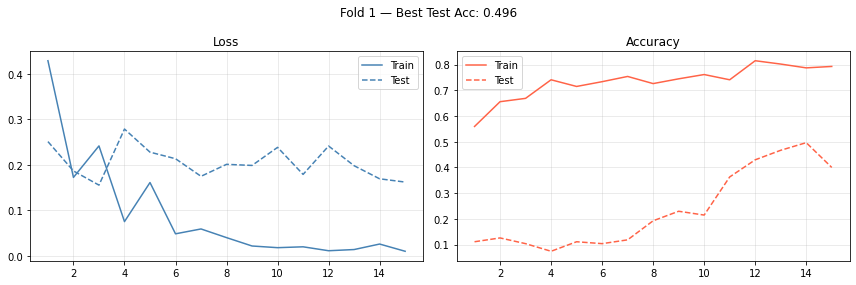


  === Fold 1 — Classification Report (argmax) ===
               precision    recall  f1-score   support

       normal       1.00      0.45      0.62       114
      preterm       0.08      0.40      0.14         5
          HIE       0.28      0.90      0.43        10
hydrocephalus       0.18      0.83      0.29         6

     accuracy                           0.50       135
    macro avg       0.39      0.65      0.37       135
 weighted avg       0.88      0.50      0.57       135

  ROC-AUC (macro OvR): 0.8429


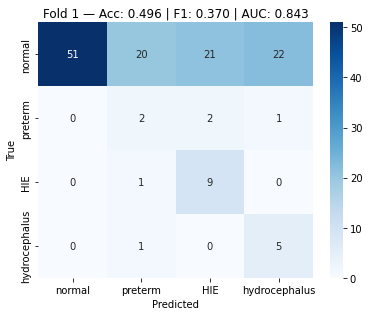


  FOLD 2/5
  Train: 540  Test: 135
  Train dist: {'normal': 453, 'HIE': 40, 'hydrocephalus': 26, 'preterm': 21}
  Test  dist: {'normal': 113, 'HIE': 10, 'preterm': 6, 'hydrocephalus': 6}
  Model initialized from random weights (no pretrained backbone).
  Class weights: {'normal': 0.078, 'preterm': 1.681, 'HIE': 0.883, 'hydrocephalus': 1.358}
  Epoch 01/15 | Train 0.438/0.552 | Test 0.230/0.119 ✓
  Epoch 02/15 | Train 0.229/0.678 | Test 0.385/0.059
  Epoch 03/15 | Train 0.193/0.665 | Test 0.249/0.119
  Epoch 04/15 | Train 0.054/0.711 | Test 0.227/0.126 ✓
  Epoch 05/15 | Train 0.115/0.700 | Test 0.217/0.119
  Epoch 06/15 | Train 0.103/0.689 | Test 0.320/0.111
  Epoch 07/15 | Train 0.054/0.711 | Test 0.152/0.126
  Epoch 08/15 | Train 0.054/0.735 | Test 0.208/0.126
  Epoch 09/15 | Train 0.020/0.743 | Test 0.186/0.193 ✓
  Epoch 10/15 | Train 0.026/0.781 | Test 0.227/0.215 ✓
  Epoch 11/15 | Train 0.024/0.744 | Test 0.213/0.244 ✓
  Epoch 12/15 | Train 0.018/0.787 | Test 0.212/0.311 ✓
  Epoch

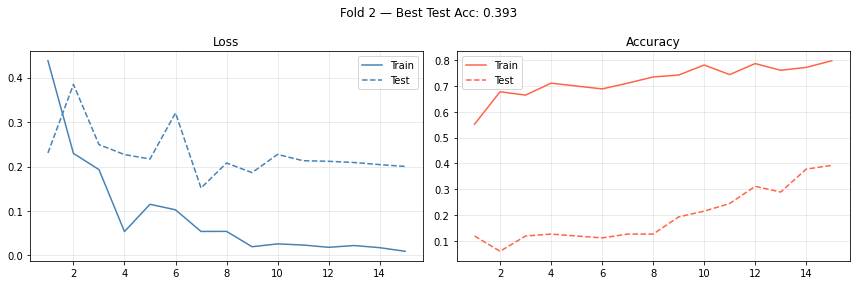


  === Fold 2 — Classification Report (argmax) ===
               precision    recall  f1-score   support

       normal       1.00      0.32      0.48       113
      preterm       0.11      0.67      0.18         6
          HIE       0.27      0.80      0.40        10
hydrocephalus       0.16      0.83      0.27         6

     accuracy                           0.39       135
    macro avg       0.38      0.65      0.33       135
 weighted avg       0.87      0.39      0.45       135

  ROC-AUC (macro OvR): 0.8312


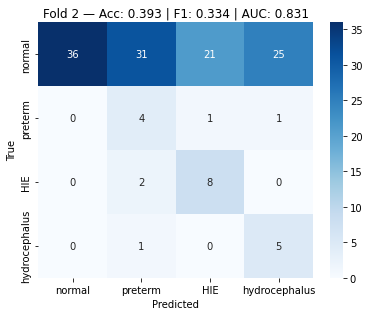


  FOLD 3/5
  Train: 540  Test: 135
  Train dist: {'normal': 453, 'HIE': 40, 'hydrocephalus': 26, 'preterm': 21}
  Test  dist: {'normal': 113, 'HIE': 10, 'hydrocephalus': 6, 'preterm': 6}
  Model initialized from random weights (no pretrained backbone).
  Class weights: {'normal': 0.078, 'preterm': 1.681, 'HIE': 0.883, 'hydrocephalus': 1.358}
  Epoch 01/15 | Train 0.424/0.546 | Test 0.281/0.089 ✓
  Epoch 02/15 | Train 0.165/0.700 | Test 0.194/0.126 ✓
  Epoch 03/15 | Train 0.150/0.704 | Test 0.247/0.089
  Epoch 04/15 | Train 0.167/0.694 | Test 0.265/0.089
  Epoch 05/15 | Train 0.080/0.728 | Test 0.299/0.104
  Epoch 06/15 | Train 0.021/0.772 | Test 0.241/0.119
  Epoch 07/15 | Train 0.052/0.711 | Test 0.205/0.141 ✓
  Epoch 08/15 | Train 0.032/0.752 | Test 0.240/0.200 ✓
  Epoch 09/15 | Train 0.035/0.754 | Test 0.285/0.304 ✓
  Epoch 10/15 | Train 0.016/0.785 | Test 0.256/0.378 ✓
  Epoch 11/15 | Train 0.020/0.785 | Test 0.251/0.252
  Epoch 12/15 | Train 0.021/0.806 | Test 0.262/0.385 ✓
  Epo

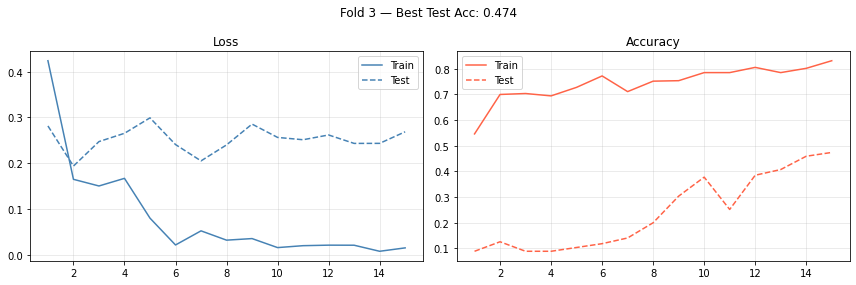


  === Fold 3 — Classification Report (argmax) ===
               precision    recall  f1-score   support

       normal       0.95      0.47      0.63       113
      preterm       0.00      0.00      0.00         6
          HIE       0.25      0.80      0.38        10
hydrocephalus       0.10      0.50      0.16         6

     accuracy                           0.47       135
    macro avg       0.32      0.44      0.29       135
 weighted avg       0.82      0.47      0.56       135

  ROC-AUC (macro OvR): 0.7664


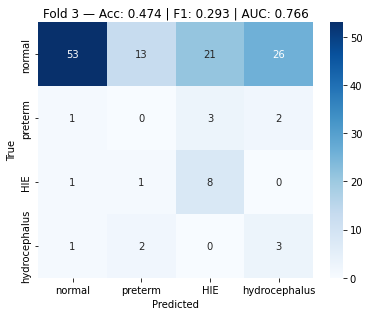


  FOLD 4/5
  Train: 540  Test: 135
  Train dist: {'normal': 453, 'HIE': 40, 'hydrocephalus': 25, 'preterm': 22}
  Test  dist: {'normal': 113, 'HIE': 10, 'hydrocephalus': 7, 'preterm': 5}
  Model initialized from random weights (no pretrained backbone).
  Class weights: {'normal': 0.078, 'preterm': 1.614, 'HIE': 0.888, 'hydrocephalus': 1.42}
  Epoch 01/15 | Train 0.401/0.574 | Test 0.173/0.119 ✓
  Epoch 02/15 | Train 0.241/0.650 | Test 1.312/0.052
  Epoch 03/15 | Train 0.137/0.698 | Test 0.399/0.111
  Epoch 04/15 | Train 0.112/0.685 | Test 0.190/0.104
  Epoch 05/15 | Train 0.088/0.719 | Test 0.223/0.111
  Epoch 06/15 | Train 0.093/0.717 | Test 0.195/0.126 ✓
  Epoch 07/15 | Train 0.024/0.746 | Test 0.213/0.133 ✓
  Epoch 08/15 | Train 0.023/0.733 | Test 0.164/0.304 ✓
  Epoch 09/15 | Train 0.048/0.761 | Test 0.182/0.274
  Epoch 10/15 | Train 0.026/0.804 | Test 0.216/0.363 ✓
  Epoch 11/15 | Train 0.026/0.724 | Test 0.212/0.356
  Epoch 12/15 | Train 0.023/0.750 | Test 0.199/0.474 ✓
  Epoch 

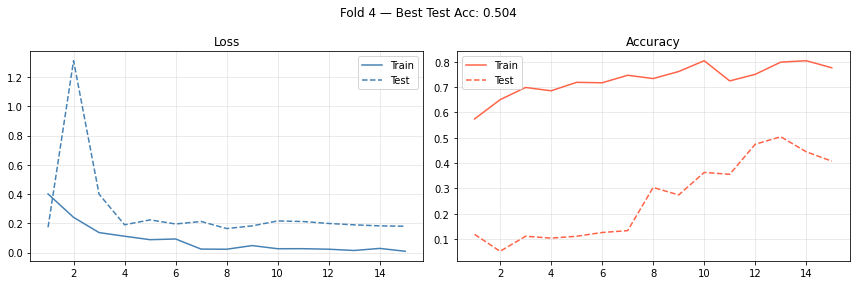


  === Fold 4 — Classification Report (argmax) ===
               precision    recall  f1-score   support

       normal       1.00      0.46      0.63       113
      preterm       0.09      0.40      0.14         5
          HIE       0.26      0.90      0.41        10
hydrocephalus       0.19      0.71      0.30         7

     accuracy                           0.50       135
    macro avg       0.39      0.62      0.37       135
 weighted avg       0.87      0.50      0.58       135

  ROC-AUC (macro OvR): 0.8173


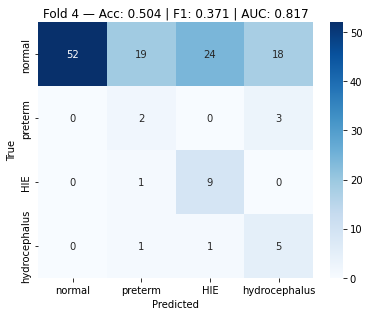


  FOLD 5/5
  Train: 540  Test: 135
  Train dist: {'normal': 453, 'HIE': 40, 'hydrocephalus': 25, 'preterm': 22}
  Test  dist: {'normal': 113, 'HIE': 10, 'hydrocephalus': 7, 'preterm': 5}
  Model initialized from random weights (no pretrained backbone).
  Class weights: {'normal': 0.078, 'preterm': 1.614, 'HIE': 0.888, 'hydrocephalus': 1.42}
  Epoch 01/15 | Train 0.411/0.596 | Test 0.380/0.052 ✓
  Epoch 02/15 | Train 0.223/0.643 | Test 0.396/0.074 ✓
  Epoch 03/15 | Train 0.115/0.678 | Test 0.278/0.119 ✓
  Epoch 04/15 | Train 0.169/0.672 | Test 0.630/0.052
  Epoch 05/15 | Train 0.154/0.687 | Test 0.229/0.126 ✓
  Epoch 06/15 | Train 0.042/0.720 | Test 0.157/0.156 ✓
  Epoch 07/15 | Train 0.022/0.730 | Test 0.145/0.319 ✓
  Epoch 08/15 | Train 0.028/0.763 | Test 0.118/0.267
  Epoch 09/15 | Train 0.036/0.774 | Test 0.147/0.356 ✓
  Epoch 10/15 | Train 0.052/0.700 | Test 0.152/0.341
  Epoch 11/15 | Train 0.039/0.748 | Test 0.135/0.415 ✓
  Epoch 12/15 | Train 0.022/0.794 | Test 0.137/0.341
  Ep

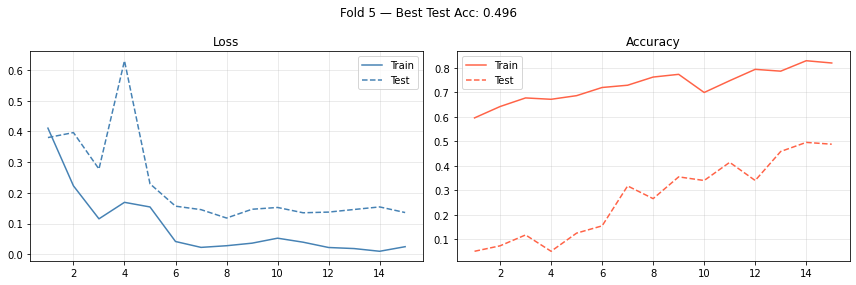


  === Fold 5 — Classification Report (argmax) ===
               precision    recall  f1-score   support

       normal       0.96      0.44      0.61       113
      preterm       0.08      0.20      0.11         5
          HIE       0.30      0.90      0.45        10
hydrocephalus       0.17      1.00      0.30         7

     accuracy                           0.50       135
    macro avg       0.38      0.64      0.37       135
 weighted avg       0.84      0.50      0.56       135

  ROC-AUC (macro OvR): 0.8245


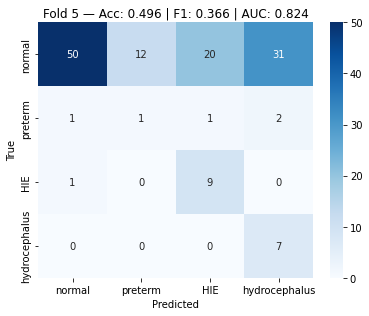


Best classifier: fold 4 (macro F1=0.3713, acc=0.5037) → saved as best_brain_classifier_4class.pth

  5-FOLD CV SUMMARY  (argmax threshold)
  auc                   0.8165 ± 0.0264  [0.7664, 0.8429]
  acc                   0.4726 ± 0.0412  [0.3926, 0.5037]
  macro_f1              0.3467 ± 0.0304  [0.2926, 0.3713]
  f1_normal             0.5930 ± 0.0555  [0.4832, 0.6303]
  f1_preterm            0.1147 ± 0.0617  [0.0000, 0.1818]
  f1_HIE                0.4137 ± 0.0237  [0.3810, 0.4500]
  f1_hydrocephalus      0.2655 ± 0.0529  [0.1622, 0.3030]

Saved: kfold_clf4_summary.csv


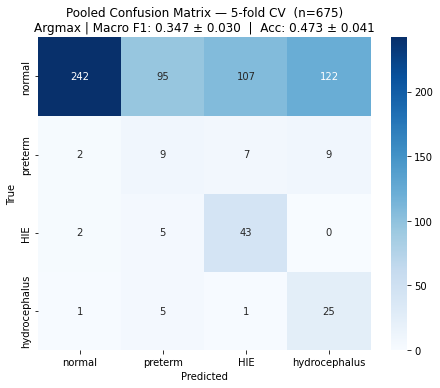


  THRESHOLD CALIBRATION  (pooled CV)
  normal           best threshold = 0.023  →  F1 = 0.928
  preterm          best threshold = 0.700  →  F1 = 0.179
  HIE              best threshold = 0.785  →  F1 = 0.571
  hydrocephalus    best threshold = 0.916  →  F1 = 0.588


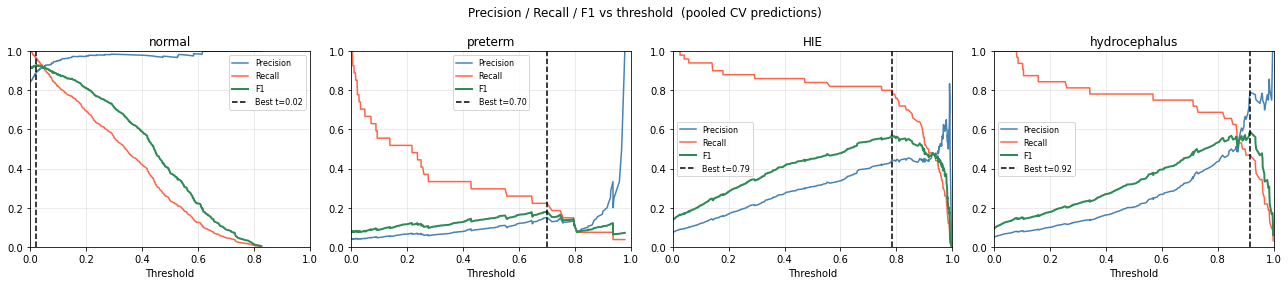


  CLASSIFICATION REPORT — calibrated thresholds (pooled CV)
               precision    recall  f1-score   support

       normal       0.91      0.89      0.90       566
      preterm       0.13      0.15      0.14        27
          HIE       0.44      0.68      0.54        50
hydrocephalus       0.78      0.44      0.56        32

     accuracy                           0.82       675
    macro avg       0.57      0.54      0.53       675
 weighted avg       0.84      0.82      0.83       675

  Macro F1 (calibrated): 0.5335
  ROC-AUC  (unchanged):  0.8103

  Calibrated thresholds: normal=0.023, preterm=0.700, HIE=0.785, hydrocephalus=0.916

Saved: calibrated_thresholds_4class.csv


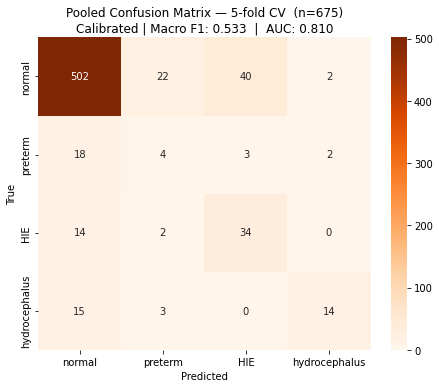

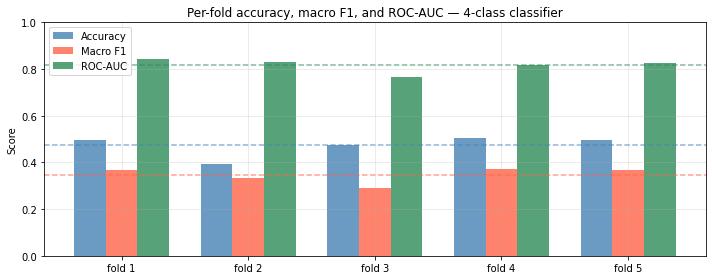

In [7]:
# =====================================================================
# BRAIN CLASSIFIER — normal / preterm / HIE / hydrocephalus
# 5-fold stratified cross-validation
#   • checkpoint save/skip per fold
#   • focal loss (gamma=1)
#   • post-hoc threshold calibration on pooled CV predictions
#   • best fold saved as deployment model
#   • mixed preterm+HIE / preterm+hydrocephalus cases folded into preterm
# Backbone: randomly initialized (no pretrained checkpoint)
# =====================================================================

import os
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score,
                             precision_recall_curve)
from monai.networks.nets import resnet18
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

# ── 0. Config ─────────────────────────────────────────────────────────
CLASS_NAMES  = ['normal', 'preterm', 'HIE', 'hydrocephalus']
NUM_CLASSES  = 4
N_FOLDS      = 5
RANDOM_STATE = 42
EPOCHS_CLF   = 15
BATCH_CLF    = 4
BEST_CLF_OUT = 'best_brain_classifier_4class.pth'

# ── 1. Label assignment (preterm takes priority over HIE/hydrocephalus) ─
def assign_clf_label(d):
    """
    0 = normal
    1 = preterm   (includes preterm+HIE and preterm+hydrocephalus comorbidity —
                   prematurity is treated as the dominant structural confound)
    2 = HIE
    3 = hydrocephalus
   -1 = excluded (anything else, e.g. polymicrogyria)
    """
    d = str(d).lower().strip()
    is_preterm = ('preterm' in d) or ('premature' in d)
    if is_preterm:
        return 1
    if d == 'normal':
        return 0
    if 'hie' in d or 'hypoxic' in d:
        return 2
    if 'hydrocephal' in d:
        return 3
    return -1

df_valid['label_clf'] = df_valid['diagnosis'].apply(assign_clf_label)
df_clf = df_valid[df_valid['label_clf'] >= 0].copy().reset_index(drop=True)

print('=== Classifier dataset (4-class, mixed cases folded into preterm) ===')
print(df_clf['label_clf'].value_counts()
      .rename({i: n for i, n in enumerate(CLASS_NAMES)}))
print(f'Total: {len(df_clf)}\n')

# Sanity check: how many preterm subjects are actually comorbid with HIE/hydrocephalus
mask_comorbid = df_clf['diagnosis'].str.lower().str.contains('preterm|premature', regex=True, na=False) & \
                df_clf['diagnosis'].str.lower().str.contains('hie|hypoxic|hydrocephal', regex=True, na=False)
print(f'Preterm subjects with HIE/hydrocephalus comorbidity (folded into preterm class): {mask_comorbid.sum()}')

# ── 2. Dataset ────────────────────────────────────────────────────────
class ClfDataset(Dataset):
    def __init__(self, dataframe, transforms):
        self.df         = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        d   = self.transforms({'t1': row['t1_path'], 't2': row['t2_path']})
        img = d['image']
        lbl = torch.tensor(row['label_clf'], dtype=torch.long)
        return img, lbl

# ── 3. Model factory ──────────────────────────────────────────────────
def make_model():
    model = resnet18(
        pretrained=False,
        spatial_dims=3,
        n_input_channels=2,
        num_classes=NUM_CLASSES
    ).to(device)
    print('  Model initialized from random weights (no pretrained backbone).')
    return model

# ── 4. Focal loss ─────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=1.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt  = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

# ── 5. One training / eval epoch ─────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            total_loss += loss.item() * len(labels)
            correct    += (preds == labels).sum().item()
            total      += len(labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    return (total_loss / total,
            correct / total,
            np.array(all_preds),
            np.array(all_labels),
            np.array(all_probs))

# ── 6. Cross-validation loop ──────────────────────────────────────────
skf             = StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                                  random_state=RANDOM_STATE)
fold_metrics    = defaultdict(list)
all_preds_pool  = []
all_labels_pool = []
all_probs_pool  = []

for fold, (train_idx, test_idx) in enumerate(
        skf.split(df_clf, df_clf['label_clf']), start=1):

    print(f'\n{"="*60}')
    print(f'  FOLD {fold}/{N_FOLDS}')
    print(f'{"="*60}')

    save_path = f'best_clf4_fold{fold:02d}.pth'

    train_df = df_clf.iloc[train_idx].reset_index(drop=True)
    test_df  = df_clf.iloc[test_idx].reset_index(drop=True)

    print(f'  Train: {len(train_df)}  Test: {len(test_df)}')
    print('  Train dist:', train_df['label_clf'].value_counts()
          .rename({i: n for i, n in enumerate(CLASS_NAMES)}).to_dict())
    print('  Test  dist:', test_df['label_clf'].value_counts()
          .rename({i: n for i, n in enumerate(CLASS_NAMES)}).to_dict())

    # ── 6a. Weighted sampler ──────────────────────────────────────────
    label_counts   = train_df['label_clf'].value_counts()
    sample_weights = train_df['label_clf'].map(1.0 / label_counts).values
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(train_df),
        replacement=True
    )

    train_loader = DataLoader(
        ClfDataset(train_df, mri_transforms),
        batch_size=BATCH_CLF, sampler=sampler,
        num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        ClfDataset(test_df, mri_transforms),
        batch_size=BATCH_CLF, shuffle=False,
        num_workers=2, pin_memory=True
    )

    # ── 6b. Model / loss / optimiser — fresh per fold ─────────────────
    model  = make_model()
    counts = np.bincount(train_df['label_clf'], minlength=NUM_CLASSES).astype(float)
    cls_w  = torch.FloatTensor(1.0 / counts).to(device)
    cls_w  = cls_w / cls_w.mean()

    criterion = FocalLoss(alpha=cls_w, gamma=1.0)
    optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_CLF, eta_min=1e-6)

    print(f'  Class weights: {dict(zip(CLASS_NAMES, cls_w.cpu().numpy().round(3)))}')

    # ── 6c. Skip if checkpoint exists ─────────────────────────────────
    if os.path.exists(save_path):
        print(f'  [SKIP] Found existing checkpoint {save_path} — loading directly.')
        model.load_state_dict(torch.load(save_path, map_location=device,
                                         weights_only=False))
        best_acc = None
    else:
        best_acc = 0.0
        history  = defaultdict(list)

        for epoch in range(1, EPOCHS_CLF + 1):
            tr_loss, tr_acc, *_ = run_epoch(model, train_loader, criterion, optimizer)
            te_loss, te_acc, *_ = run_epoch(model, test_loader,  criterion)
            scheduler.step()

            history['train_loss'].append(tr_loss)
            history['train_acc'].append(tr_acc)
            history['test_loss'].append(te_loss)
            history['test_acc'].append(te_acc)

            flag = ''
            if te_acc > best_acc:
                best_acc = te_acc
                torch.save(model.state_dict(), save_path)
                flag = ' ✓'

            print(f'  Epoch {epoch:02d}/{EPOCHS_CLF} | '
                  f'Train {tr_loss:.3f}/{tr_acc:.3f} | '
                  f'Test {te_loss:.3f}/{te_acc:.3f}{flag}')

        # Training curves
        ep = range(1, EPOCHS_CLF + 1)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(ep, history['train_loss'], label='Train', color='steelblue')
        axes[0].plot(ep, history['test_loss'],  label='Test',  color='steelblue', linestyle='--')
        axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[1].plot(ep, history['train_acc'],  label='Train', color='tomato')
        axes[1].plot(ep, history['test_acc'],   label='Test',  color='tomato',    linestyle='--')
        axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
        plt.suptitle(f'Fold {fold} — Best Test Acc: {best_acc:.3f}')
        plt.tight_layout()
        plt.savefig(f'clf4_curves_fold{fold:02d}.png', dpi=120)
        plt.show()

        model.load_state_dict(torch.load(save_path, map_location=device,
                                          weights_only=False))

    # ── 6d. Evaluate ──────────────────────────────────────────────────
    _, te_acc_eval, preds, labels, probs = run_epoch(model, test_loader, criterion)
    if best_acc is None:
        best_acc = te_acc_eval

    print(f'\n  === Fold {fold} — Classification Report (argmax) ===')
    print(classification_report(labels, preds,
                                 target_names=CLASS_NAMES, zero_division=0))

    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro')
        print(f'  ROC-AUC (macro OvR): {auc:.4f}')
        fold_metrics['auc'].append(auc)
    except Exception as e:
        print(f'  AUC skipped: {e}')
        fold_metrics['auc'].append(np.nan)

    fold_metrics['acc'].append(best_acc)
    fold_metrics['macro_f1'].append(
        f1_score(labels, preds, average='macro', zero_division=0))
    for i, name in enumerate(CLASS_NAMES):
        fold_metrics[f'f1_{name}'].append(
            f1_score(labels == i, preds == i, zero_division=0))

    # Accumulate for pooled evaluation and threshold calibration
    all_preds_pool.extend(preds)
    all_labels_pool.extend(labels)
    all_probs_pool.extend(probs)

    # Per-fold confusion matrix
    cm_fold = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm_fold, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    auc_str = (f'{fold_metrics["auc"][-1]:.3f}'
               if not np.isnan(fold_metrics['auc'][-1]) else 'N/A')
    ax.set_title(f'Fold {fold} — Acc: {best_acc:.3f} | '
                 f'F1: {fold_metrics["macro_f1"][-1]:.3f} | '
                 f'AUC: {auc_str}')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_4class_fold{fold:02d}.png', dpi=120)
    plt.show()

# ── 7. Save overall best fold ─────────────────────────────────────────
best_idx  = np.argmax(fold_metrics['macro_f1'])
best_fold = best_idx + 1
shutil.copy(f'best_clf4_fold{best_fold:02d}.pth', BEST_CLF_OUT)
print(f'\nBest classifier: fold {best_fold} '
      f'(macro F1={fold_metrics["macro_f1"][best_idx]:.4f}, '
      f'acc={fold_metrics["acc"][best_idx]:.4f})'
      f' → saved as {BEST_CLF_OUT}')

# ── 8. Aggregate summary ──────────────────────────────────────────────
print(f'\n{"="*60}')
print('  5-FOLD CV SUMMARY  (argmax threshold)')
print(f'{"="*60}')
summary_rows = []
for key, vals in fold_metrics.items():
    arr = np.array(vals)
    summary_rows.append({'metric': key,
                         'mean':   arr.mean(),
                         'std':    arr.std(),
                         'min':    arr.min(),
                         'max':    arr.max()})
    print(f'  {key:<20s}  {arr.mean():.4f} ± {arr.std():.4f}'
          f'  [{arr.min():.4f}, {arr.max():.4f}]')

summary_df = pd.DataFrame(summary_rows).set_index('metric')
summary_df.to_csv('kfold_clf4_summary.csv')
print('\nSaved: kfold_clf4_summary.csv')

# ── 9. Pooled confusion matrix (argmax) ───────────────────────────────
all_labels_pool = np.array(all_labels_pool)
all_preds_pool  = np.array(all_preds_pool)
all_probs_pool  = np.array(all_probs_pool)   # shape [N, 4]

cm = confusion_matrix(all_labels_pool, all_preds_pool)
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title(f'Pooled Confusion Matrix — {N_FOLDS}-fold CV  (n={len(all_labels_pool)})\n'
          f'Argmax | Macro F1: {np.mean(fold_metrics["macro_f1"]):.3f} ± '
          f'{np.std(fold_metrics["macro_f1"]):.3f}  |  '
          f'Acc: {np.mean(fold_metrics["acc"]):.3f} ± '
          f'{np.std(fold_metrics["acc"]):.3f}')
plt.tight_layout()
plt.savefig('confusion_matrix_4class_kfold_argmax.png', dpi=120)
plt.show()

# ── 10. Threshold calibration ─────────────────────────────────────────
print(f'\n{"="*60}')
print('  THRESHOLD CALIBRATION  (pooled CV)')
print(f'{"="*60}')

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 4))
best_thresholds = {}

for i, name in enumerate(CLASS_NAMES):
    binary_labels = (all_labels_pool == i).astype(int)
    precision, recall, thresholds = precision_recall_curve(
        binary_labels, all_probs_pool[:, i])

    f1_scores = (2 * precision * recall /
                 (precision + recall + 1e-8))
    best_t_idx           = np.argmax(f1_scores[:-1])
    best_thresholds[i]   = float(thresholds[best_t_idx])

    print(f'  {name:<15s}  best threshold = {best_thresholds[i]:.3f}'
          f'  →  F1 = {f1_scores[best_t_idx]:.3f}')

    axes[i].plot(thresholds, precision[:-1], label='Precision', color='steelblue')
    axes[i].plot(thresholds, recall[:-1],    label='Recall',    color='tomato')
    axes[i].plot(thresholds, f1_scores[:-1], label='F1',        color='seagreen', linewidth=2)
    axes[i].axvline(best_thresholds[i], color='black', linestyle='--',
                    label=f'Best t={best_thresholds[i]:.2f}')
    axes[i].set_xlabel('Threshold'); axes[i].set_title(name)
    axes[i].legend(fontsize=8); axes[i].grid(alpha=0.3)
    axes[i].set_xlim(0, 1); axes[i].set_ylim(0, 1)

plt.suptitle('Precision / Recall / F1 vs threshold  (pooled CV predictions)')
plt.tight_layout()
plt.savefig('threshold_curves_4class.png', dpi=120)
plt.show()

# ── 11. Apply calibrated thresholds ──────────────────────────────────
shifted_scores    = np.stack(
    [all_probs_pool[:, i] - best_thresholds[i] for i in range(NUM_CLASSES)],
    axis=1)
calibrated_preds  = np.argmax(shifted_scores, axis=1)

print(f'\n{"="*60}')
print('  CLASSIFICATION REPORT — calibrated thresholds (pooled CV)')
print(f'{"="*60}')
print(classification_report(all_labels_pool, calibrated_preds,
                             target_names=CLASS_NAMES, zero_division=0))

cal_macro_f1 = f1_score(all_labels_pool, calibrated_preds,
                         average='macro', zero_division=0)
try:
    cal_auc = roc_auc_score(all_labels_pool, all_probs_pool,
                             multi_class='ovr', average='macro')
except Exception:
    cal_auc = float('nan')

print(f'  Macro F1 (calibrated): {cal_macro_f1:.4f}')
print(f'  ROC-AUC  (unchanged):  {cal_auc:.4f}')
print(f'\n  Calibrated thresholds: '
      + ', '.join([f'{CLASS_NAMES[i]}={best_thresholds[i]:.3f}'
                   for i in range(NUM_CLASSES)]))

threshold_df = pd.DataFrame([{'class': CLASS_NAMES[i],
                               'threshold': best_thresholds[i]}
                              for i in range(NUM_CLASSES)])
threshold_df.to_csv('calibrated_thresholds_4class.csv', index=False)
print('\nSaved: calibrated_thresholds_4class.csv')

# ── 12. Pooled confusion matrix (calibrated) ─────────────────────────
cm_cal = confusion_matrix(all_labels_pool, calibrated_preds)
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm_cal, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title(f'Pooled Confusion Matrix — {N_FOLDS}-fold CV  (n={len(all_labels_pool)})\n'
          f'Calibrated | Macro F1: {cal_macro_f1:.3f}  |  AUC: {cal_auc:.3f}')
plt.tight_layout()
plt.savefig('confusion_matrix_4class_kfold_calibrated.png', dpi=120)
plt.show()

# ── 13. Per-fold accuracy + F1 + AUC bar plot ─────────────────────────
x     = np.arange(N_FOLDS)
width = 0.25
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, fold_metrics['acc'],      width, label='Accuracy', color='steelblue', alpha=0.8)
ax.bar(x,         fold_metrics['macro_f1'], width, label='Macro F1', color='tomato',    alpha=0.8)
ax.bar(x + width, fold_metrics['auc'],      width, label='ROC-AUC',  color='seagreen',  alpha=0.8)
ax.axhline(np.mean(fold_metrics['acc']),      color='steelblue', linestyle='--', alpha=0.6)
ax.axhline(np.mean(fold_metrics['macro_f1']), color='tomato',    linestyle='--', alpha=0.6)
ax.axhline(np.nanmean(fold_metrics['auc']),   color='seagreen',  linestyle='--', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f'fold {i}' for i in range(1, N_FOLDS + 1)])
ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title('Per-fold accuracy, macro F1, and ROC-AUC — 4-class classifier')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kfold_scores_bar_4class.png', dpi=120)
plt.show()

## 8. Notes
- **Backbone**: 3D ResNet-18 (MONAI), trained **from random initialization** — no pretrained age-regression checkpoint. **Hyperparameters** are otherwise unchanged from the original 3-class classifier: `lr=5e-5`, `weight_decay=1e-4`, `AdamW`, `CosineAnnealingLR(T_max=15)`, `BATCH_CLF=4`, `EPOCHS_CLF=15`, 5-fold stratified CV, focal loss with `gamma=1.0` and inverse-frequency class weights, a class-balanced `WeightedRandomSampler`, and post-hoc per-class threshold calibration on pooled CV predictions.
- **Mixed-case handling**: `assign_clf_label` checks for `'preterm'`/`'premature'` *first*, so any subject whose diagnosis string also mentions HIE or hydrocephalus (i.e. a comorbid case) still lands in the preterm class rather than being split out or dropped. Adjust the regex/order if you'd rather exclude comorbid cases entirely or give them their own class.
- **Class imbalance**: with 4 classes instead of 3, expect more skew (preterm is usually the largest non-normal group once comorbidities are folded in) — keep an eye on the printed class weights and per-fold train/test distributions; if a class has very few subjects per fold, consider reducing `N_FOLDS` or merging classes further.
- Re-run Sections 6–9 of the original `myelin_age_gap_classifier.ipynb` first if `best_age_regressor.pth` doesn't already exist in your working directory.